# B9D54_10_Trần Văn Quang Khải_ATMobile

# Detecting Android Malware with Mendeley Android Permissions Dataset
## Thực nghiệm mở rộng: DistilBERTroid-Permission trên bộ dữ liệu Mendeley

Notebook này được thiết kế để sử dụng bộ dữ liệu **Android permissions dataset, Android Malware and benign Application Data set** trên Mendeley Data.

Mục tiêu:
1. Đọc dữ liệu permission/API calls từ Mendeley.
2. Chuẩn hóa dữ liệu về định dạng chung: `app_id, permissions, label, source_dataset`.
3. Lấy mẫu cân bằng giữa benign và malware.
4. Huấn luyện mô hình **DistilBERTroid-Permission**.
5. So sánh thêm với baseline truyền thống: TF-IDF + Logistic Regression và TF-IDF + Linear SVM.
6. Xuất bảng kết quả, biểu đồ loss, metric, confusion matrix, ROC curve, Precision-Recall curve để đưa vào tiểu luận.

Ghi chú:
- Dataset Mendeley có thể lớn, nên notebook có biến cấu hình để giới hạn số mẫu mỗi lớp.
- Nếu máy/GPU mạnh, tăng `TARGET_SAMPLES_PER_CLASS`.
- Nếu bị thiếu RAM, giảm `TARGET_SAMPLES_PER_CLASS` hoặc dùng `LOAD_NROWS`.

## 0. Cài đặt thư viện và cấu hình môi trường

Chạy cell dưới đây trước.  
Nếu dùng Google Colab, nên chọn GPU:

`Runtime → Change runtime type → Hardware accelerator → GPU`

In [ ]:
# Cài đặt các thư viện cần thiết.
# transformers: dùng DistilBERT.
# accelerate: hỗ trợ tăng tốc huấn luyện.
# openpyxl: đọc file Excel nếu dataset có .xlsx.
!pip install -q transformers accelerate openpyxl

# Thư viện hệ thống.
import os
import re
import json
import time
import zipfile
import shutil
import random
from pathlib import Path

# Thư viện xử lý dữ liệu.
import numpy as np
import pandas as pd

# Thư viện trực quan hóa.
import matplotlib.pyplot as plt

# PyTorch.
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

# Hugging Face Transformers.
from transformers import DistilBertTokenizerFast, DistilBertModel
from transformers import get_linear_schedule_with_warmup

# Scikit-learn: chia dữ liệu và đánh giá.
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)

# Baseline truyền thống.
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

# Cố định seed để kết quả có khả năng tái lập tương đối.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Tối ưu tốc độ GPU.
FAST_TRAINING = True
torch.backends.cudnn.benchmark = FAST_TRAINING
torch.backends.cudnn.deterministic = not FAST_TRAINING

# Chọn thiết bị.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Thiết bị sử dụng:", device)

if torch.cuda.is_available():
    print("Tên GPU:", torch.cuda.get_device_name(0))

# Bật mixed precision nếu có GPU.
USE_AMP = torch.cuda.is_available()
print("Sử dụng mixed precision:", USE_AMP)

Thiết bị sử dụng: cuda
Tên GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
Sử dụng mixed precision: True


## 1. Tải hoặc dùng lại bộ dữ liệu Mendeley từ Google Drive

Notebook đã được chỉnh để **không phải upload file ZIP mỗi lần chạy lại**.

Cơ chế hoạt động:

1. Lần đầu chạy: upload file `Download All` từ Mendeley (`.zip`) hoặc file `.xlsx/.csv`.
2. Notebook tự lưu file gốc vào Google Drive tại:
   `MyDrive/ATMobile_Mendeley/raw/`
3. Nếu là file `.zip`, notebook tự giải nén vào:
   `MyDrive/ATMobile_Mendeley/extracted/`
4. Sau khi đọc Excel lần đầu, notebook tạo cache CSV tại:
   `MyDrive/ATMobile_Mendeley/cache/mendeley_android_permissions_cached.csv`
5. Những lần chạy sau: chỉ cần mount Drive, notebook tự đọc cache CSV, không cần upload lại.


In [ ]:
from google.colab import files, drive

# ============================================================
# CƠ CHẾ LƯU DATASET VÀ CACHE TRÊN GOOGLE DRIVE
# ============================================================
# Mục tiêu:
# - Lần đầu: upload file Download All từ Mendeley (.zip/.xlsx/.csv).
# - Notebook tự lưu file gốc vào Google Drive.
# - Lần sau: chỉ cần mount Drive, không cần upload lại.
# - Sau khi đọc Excel lần đầu, notebook tạo file CSV cache để đọc nhanh hơn.

# Mount Google Drive để lưu file gốc và cache lâu dài.
drive.mount('/content/drive')

# Thư mục gốc lưu toàn bộ dữ liệu của thực nghiệm Mendeley trên Drive.
DRIVE_PROJECT_DIR = Path('/content/drive/MyDrive/ATMobile_Mendeley')

# Thư mục lưu file gốc tải từ Mendeley, ví dụ b4mxg7ydb7-3.zip hoặc computer and security_2.xlsx.
DRIVE_RAW_DIR = DRIVE_PROJECT_DIR / 'raw'

# Thư mục lưu file đã giải nén.
DRIVE_EXTRACT_DIR = DRIVE_PROJECT_DIR / 'extracted'

# Thư mục lưu CSV cache sau khi đọc Excel lần đầu.
DRIVE_CACHE_DIR = DRIVE_PROJECT_DIR / 'cache'

# Tạo các thư mục nếu chưa tồn tại.
for directory in [DRIVE_PROJECT_DIR, DRIVE_RAW_DIR, DRIVE_EXTRACT_DIR, DRIVE_CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Đường dẫn file cache CSV. Nếu file này tồn tại, notebook sẽ đọc nó thay vì đọc lại Excel.
CACHE_CSV_PATH = DRIVE_CACHE_DIR / 'mendeley_android_permissions_cached.csv'

# Các định dạng dữ liệu được hỗ trợ.
supported_exts = ['.csv', '.txt', '.tsv', '.xlsx', '.xls']
archive_exts = ['.zip']

# Tìm file dữ liệu hoặc file zip đã có sẵn trên Drive.
raw_files = [p for p in DRIVE_RAW_DIR.rglob('*') if p.is_file()]
existing_archives = [p for p in raw_files if p.suffix.lower() in archive_exts]
existing_data_files = [p for p in raw_files if p.suffix.lower() in supported_exts]

print('Thư mục raw trên Drive:', DRIVE_RAW_DIR)
print('Số file gốc đã có trên Drive:', len(raw_files))

# Nếu chưa có cache và cũng chưa có file gốc trên Drive, yêu cầu upload một lần.
if (not CACHE_CSV_PATH.exists()) and len(existing_archives) == 0 and len(existing_data_files) == 0:
    print('Chưa thấy file dataset trên Drive.')
    print('Vui lòng upload file Download All từ Mendeley (.zip) hoặc file .xlsx/.csv.')
    uploaded = files.upload()

    # Lưu file upload vào Drive để lần sau không cần upload lại.
    for filename in uploaded.keys():
        src_path = Path(filename)
        dst_path = DRIVE_RAW_DIR / filename
        shutil.move(str(src_path), str(dst_path))
        print('Đã lưu vào Drive:', dst_path)

# Giải nén các file zip trong DRIVE_RAW_DIR sang DRIVE_EXTRACT_DIR.
for zip_path in DRIVE_RAW_DIR.rglob('*.zip'):
    extract_dir = DRIVE_EXTRACT_DIR / zip_path.stem

    # Nếu thư mục giải nén đã có file, bỏ qua để tiết kiệm thời gian.
    already_extracted_files = list(extract_dir.rglob('*')) if extract_dir.exists() else []
    if len(already_extracted_files) > 0:
        print('Đã giải nén trước đó, bỏ qua:', extract_dir)
        continue

    extract_dir.mkdir(parents=True, exist_ok=True)
    print('Đang giải nén:', zip_path)

    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)
        print('Giải nén xong:', extract_dir)
    except zipfile.BadZipFile:
        raise zipfile.BadZipFile(
            f'File ZIP có vẻ bị lỗi hoặc tải chưa hoàn chỉnh: {zip_path}. '
            'Hãy xóa file này trong Google Drive và upload/tải lại.'
        )

# Tập hợp tất cả file dữ liệu có thể đọc từ raw và extracted.
data_files = []
for base_dir in [DRIVE_RAW_DIR, DRIVE_EXTRACT_DIR]:
    data_files.extend([
        p for p in base_dir.rglob('*')
        if p.is_file() and p.suffix.lower() in supported_exts
    ])

print('\nFile cache CSV:', CACHE_CSV_PATH)
print('Cache tồn tại:', CACHE_CSV_PATH.exists())
print('Số file dữ liệu tìm thấy:', len(data_files))

for i, p in enumerate(data_files[:50]):
    size_mb = p.stat().st_size / (1024 * 1024)
    print(f'{i:02d}. {p} | {size_mb:.2f} MB')

Mounted at /content/drive
Thư mục raw trên Drive: /content/drive/MyDrive/ATMobile_Mendeley/raw
Số file gốc đã có trên Drive: 1
Đã giải nén trước đó, bỏ qua: /content/drive/MyDrive/ATMobile_Mendeley/extracted/b4mxg7ydb7-3

File cache CSV: /content/drive/MyDrive/ATMobile_Mendeley/cache/mendeley_android_permissions_cached.csv
Cache tồn tại: True
Số file dữ liệu tìm thấy: 1
00. /content/drive/MyDrive/ATMobile_Mendeley/extracted/b4mxg7ydb7-3/computer and security_2.xlsx | 550.59 MB


## 2. Đọc dữ liệu Mendeley và gán nhãn theo sheet

Cấu trúc file Excel Mendeley gồm các sheet:

- `Google play store`: ứng dụng lành tính, gán `label = 0`.
- `Third party`: ứng dụng từ kho bên thứ ba, trong thực nghiệm này gán `label = 0` theo cách tổ chức của dataset.
- `Malware applications`: ứng dụng mã độc, gán `label = 1`.
- `list of features`: danh sách tên feature, không dùng làm dữ liệu huấn luyện.

Notebook **không còn tự tìm cột nhãn trong các cột permission** để tránh lỗi chọn nhầm một permission làm nhãn. Lần đầu đọc Excel sẽ tạo cache CSV chuẩn hóa theo sheet; các lần chạy sau chỉ đọc cache, không cần upload hoặc đọc lại Excel lớn.

In [ ]:
# ============================================================
# ĐỌC DỮ LIỆU MENDELEY VÀ GÁN NHÃN THEO SHEET
# ============================================================
# Cấu trúc file Excel quan sát được:
# - Google play store    -> benign, label = 0
# - Third party          -> benign, label = 0 trong thực nghiệm này
# - Malware applications -> malware, label = 1
# - list of features     -> danh sách feature, không dùng để train
#
# Lưu ý:
# - Không dùng cơ chế tự dò cột label vì dễ chọn nhầm cột permission nhị phân.
# - Sử dụng cache riêng mendeley_sheet_labeled_cache.csv để tránh đọc lại file Excel lớn.

# Nếu muốn chọn thủ công file Excel, điền đường dẫn vào đây.
DATA_FILE_PATH = None

# Nếu muốn chạy thử nhanh, đặt ví dụ 20000 hoặc 50000.
# Nếu muốn đọc toàn bộ dữ liệu, đặt None.
LOAD_NROWS_PER_SHEET = None

# Nếu True, notebook sẽ xóa cache sheet-label và đọc lại Excel từ đầu.
# Khi đổi LOAD_NROWS_PER_SHEET hoặc muốn đọc toàn bộ sau khi đã test, đặt True một lần.
FORCE_REBUILD_SHEET_LABEL_CACHE = True

# File cache chuẩn hóa theo sheet.
STANDARDIZED_CACHE_PATH = DRIVE_CACHE_DIR / 'mendeley_sheet_labeled_cache.csv'

# Map nhãn theo tên sheet đã chuẩn hóa.
# 0 = benign, 1 = malware
SHEET_LABEL_MAP = {
    "google play store": 0,
    "third party": 0,
    "malware applications": 1
}

# Các sheet không dùng để train.
IGNORE_SHEETS = {
    "list of features"
}

def normalize_sheet_name(sheet_name):
    """
    Chuẩn hóa tên sheet để tránh lỗi:
    - khác chữ hoa/thường
    - thừa khoảng trắng
    - nhiều khoảng trắng liên tiếp
    """
    sheet_name = str(sheet_name).strip().lower()
    sheet_name = " ".join(sheet_name.split())
    return sheet_name

# Xóa cache nếu người dùng yêu cầu rebuild.
if FORCE_REBUILD_SHEET_LABEL_CACHE and STANDARDIZED_CACHE_PATH.exists():
    STANDARDIZED_CACHE_PATH.unlink()
    print('Đã xóa cache sheet-label cũ:', STANDARDIZED_CACHE_PATH)

# Hàm chọn file Excel lớn nhất nếu DATA_FILE_PATH = None.
def choose_main_excel_file(data_files):
    """Chọn file Excel lớn nhất trong các file tìm thấy."""
    excel_files = [p for p in data_files if p.suffix.lower() in ['.xlsx', '.xls']]
    if len(excel_files) == 0:
        raise FileNotFoundError('Không tìm thấy file Excel .xlsx/.xls của Mendeley trong Drive/extracted.')
    return max(excel_files, key=lambda p: p.stat().st_size)

# Nếu đã có cache chuẩn hóa thì đọc cache.
if STANDARDIZED_CACHE_PATH.exists():
    print('Đã tìm thấy cache đã gán nhãn theo sheet. Đọc từ cache:')
    print(STANDARDIZED_CACHE_PATH)
    df = pd.read_csv(STANDARDIZED_CACHE_PATH, low_memory=False)
else:
    # Xác định file Excel chính.
    if DATA_FILE_PATH is None:
        main_file = choose_main_excel_file(data_files)
    else:
        main_file = Path(DATA_FILE_PATH)

    print('File Excel chính:', main_file)
    print('Kích thước file:', round(main_file.stat().st_size / (1024 * 1024), 2), 'MB')

    # Đọc danh sách sheet.
    xls = pd.ExcelFile(main_file)
    print('\nDanh sách sheet trong Excel:')
    for idx, sheet in enumerate(xls.sheet_names):
        print(f'{idx:02d}. {sheet}')

    frames = []

    # Đọc từng sheet và gán nhãn theo tên sheet.
    for sheet_name in xls.sheet_names:
        sheet_name_clean = str(sheet_name).strip()
        sheet_key = normalize_sheet_name(sheet_name)

        if sheet_key in IGNORE_SHEETS:
            print("\nBỏ qua sheet không phải dữ liệu train:", sheet_name_clean)
            continue

        if sheet_key not in SHEET_LABEL_MAP:
            print("\nBỏ qua sheet chưa có quy tắc gán nhãn:", sheet_name_clean)
            continue

        label = SHEET_LABEL_MAP[sheet_key]

        print(f'\nĐang đọc sheet: {sheet_name_clean} | label = {label}')

        tmp = pd.read_excel(
            main_file,
            sheet_name=sheet_name_clean,
            nrows=LOAD_NROWS_PER_SHEET,
            engine='openpyxl'
        )

        # Loại bỏ dòng rỗng hoàn toàn.
        tmp = tmp.dropna(how='all').reset_index(drop=True)

        # Thêm nhãn và sheet nguồn.
        tmp['label'] = label
        tmp['source_sheet'] = sheet_name_clean

        print('Kích thước sheet sau đọc:', tmp.shape)
        frames.append(tmp)

    if len(frames) == 0:
        raise ValueError('Không đọc được sheet dữ liệu nào. Hãy kiểm tra tên sheet trong file Excel.')

    # Ghép các sheet thành một DataFrame chung.
    df = pd.concat(frames, axis=0, ignore_index=True, sort=False)

    # Lưu cache nếu đọc toàn bộ hoặc đọc thử đều được, nhưng tên cache có chứa sheet-label để tránh nhầm cache cũ.
    STANDARDIZED_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(STANDARDIZED_CACHE_PATH, index=False)
    print('\nĐã lưu cache đã gán nhãn theo sheet:', STANDARDIZED_CACHE_PATH)

print('\nKích thước dữ liệu sau gán nhãn theo sheet:', df.shape)
print('\nPhân bố nhãn:')
print(df['label'].value_counts())

print('\nPhân bố theo sheet và nhãn:')
print(pd.crosstab(df['source_sheet'], df['label']))

# Tạo alias df_raw để các cell khảo sát phía sau vẫn chạy được.
df_raw = df.copy()

df.head()


Đã xóa cache sheet-label cũ: /content/drive/MyDrive/ATMobile_Mendeley/cache/mendeley_sheet_labeled_cache.csv
File Excel chính: /content/drive/MyDrive/ATMobile_Mendeley/extracted/b4mxg7ydb7-3/computer and security_2.xlsx
Kích thước file: 550.59 MB

Danh sách sheet trong Excel:
00. Google play store
01. Malware Applications
02. Third party
03. list of features

Đang đọc sheet: Google play store | label = 0
Kích thước sheet sau đọc: (100000, 1441)

Đang đọc sheet: Malware Applications | label = 1
Kích thước sheet sau đọc: (62899, 1440)

Đang đọc sheet: Third party | label = 0
Kích thước sheet sau đọc: (49999, 1440)

Bỏ qua sheet không phải dữ liệu train: list of features

Đã lưu cache đã gán nhãn theo sheet: /content/drive/MyDrive/ATMobile_Mendeley/cache/mendeley_sheet_labeled_cache.csv

Kích thước dữ liệu sau gán nhãn theo sheet: (212898, 1441)

Phân bố nhãn:
label
0    149999
1     62899
Name: count, dtype: int64

Phân bố theo sheet và nhãn:
label                      0      1
source_sh

,Package,Category,Total Permissions,Default : Access DRM content. (S),Default : Access Email provider data (S),Default : Access all system downloads (S),Default : Access download manager. (S),Default : Advanced download manager functions. (S),Default : Audio File Access (S),Default : Install DRM content. (S),...,ACTION_DOCK_EVENT,ACTION_GET_RESTRICTION_ENTRIES,ACTION_USER_INITIALIZE,ACTION_USER_FOREGROUND,ACTION_USER_BACKGROUND,ACTION_QUICK_CLOCK,ACTION_OPEN_DOCUMENT,ACTION_CREATE_DOCUMENT,label,source_sheet
0,a.gosms.theme.sky,Personalization,19,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.0,0,Google play store
1,a1.golfshotfixex,Sports,5,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.0,0,Google play store
2,a1.golfshotfixex,Sports,5,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.0,0,Google play store
3,a2dp.Vol,Transportation,12,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.0,0,Google play store
4,a2z.ChirpE,Business,4,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.0,0,Google play store


## 3. Khảo sát cấu trúc dữ liệu

Cell này giúp xem:
- Tên cột.
- Kiểu dữ liệu.
- Giá trị thiếu.
- Các cột có khả năng là nhãn.

In [ ]:
# In danh sách cột.
print("Danh sách cột:")
print(df_raw.columns.tolist())

# In kiểu dữ liệu của một số cột đầu.
print("\nKiểu dữ liệu 30 cột đầu:")
print(df_raw.dtypes.head(30))

# In số lượng giá trị thiếu.
print("\nGiá trị thiếu 30 cột đầu:")
print(df_raw.isnull().sum().head(30))

# In kích thước dữ liệu.
print("\nKích thước dữ liệu:", df_raw.shape)

Danh sách cột:
['Package', 'Category', 'Total Permissions', 'Default : Access DRM content. (S)', 'Default : Access Email provider data (S)', 'Default : Access all system downloads (S)', 'Default : Access download manager. (S)', 'Default : Advanced download manager functions. (S)', 'Default : Audio File Access (S)', 'Default : Install DRM content. (S)', 'Default : Modify Google service configuration (S)', 'Default : Modify Google settings (S)', 'Default : Move application resources (S)', 'Default : Read Google settings (S)', 'Default : Send download notifications. (S)', 'Default : Voice Search Shortcuts (S)', 'Default : access SurfaceFlinger (S)', 'Default : access checkin properties (S)', 'Default : access the cache filesystem (S)', 'Default : access to passwords for Google accounts (S)', 'Default : act as an account authenticator (S)', 'Default : bind to a wallpaper (S)', 'Default : bind to an input method (S)', 'Default : change screen orientation (S)', 'Default : coarse (network-bas

## 4. Kiểm tra nhãn sau khi gán theo sheet

Ở phiên bản này, nhãn được gán từ tên sheet thay vì dò từ cột dữ liệu. Điều này tránh lỗi nghiêm trọng: chọn nhầm một cột permission nhị phân làm nhãn malware/benign.

Quy ước nhãn:

- `0`: Benign
- `1`: Malware

In [ ]:
# ============================================================
# KIỂM TRA NHÃN SAU KHI GÁN THEO SHEET
# ============================================================
# Không tự động chọn cột label nữa.
# Biến label_col được đặt thành 'label' vì cell đọc dữ liệu đã tạo nhãn từ tên sheet.

label_col = 'label'

# Kiểm tra cột label có tồn tại không.
if label_col not in df.columns:
    raise ValueError('Không tìm thấy cột label. Hãy chạy lại cell đọc dữ liệu và gán nhãn theo sheet.')

# Kiểm tra dữ liệu có đủ hai lớp không.
unique_labels = sorted(df[label_col].dropna().astype(int).unique().tolist())

print('Các nhãn tìm thấy:', unique_labels)
print('\nPhân bố nhãn:')
print(df[label_col].value_counts())

print('\nPhân bố theo source_sheet:')
print(pd.crosstab(df['source_sheet'], df[label_col]))

if set(unique_labels) != {0, 1}:
    raise ValueError('Dữ liệu chưa có đủ hai lớp 0 và 1. Hãy kiểm tra SHEET_LABEL_MAP.')

print('\nCột nhãn hợp lệ: label')


Các nhãn tìm thấy: [0, 1]

Phân bố nhãn:
label
0    149999
1     62899
Name: count, dtype: int64

Phân bố theo source_sheet:
label                      0      1
source_sheet                       
Google play store     100000      0
Malware Applications       0  62899
Third party            49999      0

Cột nhãn hợp lệ: label


In [ ]:
# ============================================================
# TÓM TẮT NHÃN
# ============================================================
# 0 = Benign
# 1 = Malware

# Đảm bảo label có kiểu int.
df['label'] = df['label'].astype(int)

label_summary = pd.DataFrame({
    'label': [0, 1],
    'ý nghĩa': ['Benign', 'Malware'],
    'số lượng': [
        int((df['label'] == 0).sum()),
        int((df['label'] == 1).sum())
    ]
})

label_summary.to_csv('mendeley_label_summary.csv', index=False)
label_summary


,label,ý nghĩa,số lượng
0,0,Benign,149999
1,1,Malware,62899


## 5. Xác định các cột permission/API feature

Dataset Mendeley có thể chứa:
- Permission lúc cài đặt.
- Permission runtime.
- API calls.
- Một số metadata như tên app, package, hash, source.

Notebook sẽ loại metadata và giữ lại các cột feature dạng nhị phân hoặc dạng có/không.

In [ ]:
# ============================================================
# XÁC ĐỊNH CÁC CỘT PERMISSION/API FEATURE - BẢN ROBUST
# ============================================================
# Mục tiêu:
# - Loại metadata như Package, Category, Total Permissions, label, source_sheet.
# - Giữ các cột permission/API có phần lớn giá trị là 0/1.
# - Không bị loại toàn bộ feature chỉ vì vài ô lỗi/NaN/chuỗi lạ sau khi ghép sheet.

metadata_cols = {
    "Package",
    "Category",
    "Total Permissions",
    "label",
    "source_sheet"
}

metadata_name_keywords = [
    "unnamed:",
    "__source",
    "__sheet",
    "label",
    "class",
    "category",
    "package",
    "total permissions"
]

def is_metadata_col(col):
    """
    Kiểm tra cột có phải metadata hay không.
    """
    col_str = str(col).strip()
    col_lower = col_str.lower()

    if col_str in metadata_cols:
        return True

    return any(keyword in col_lower for keyword in metadata_name_keywords)


def normalize_binary_value(value):
    """
    Chuẩn hóa một giá trị về 0/1 nếu có thể.
    Trả về np.nan nếu không nhận diện được.
    """
    if pd.isna(value):
        return np.nan

    value_str = str(value).strip().lower()

    if value_str in ["0", "0.0", "false", "no", "n", "absent"]:
        return 0

    if value_str in ["1", "1.0", "true", "yes", "y", "present"]:
        return 1

    return np.nan


def binary_feature_score(series):
    """
    Tính mức độ giống cột nhị phân.

    Một cột được xem là feature nếu:
    - Có đủ số lượng giá trị hợp lệ.
    - Tỉ lệ giá trị nhận diện được là 0/1 đủ cao.
    - Có ít nhất một giá trị 1 hoặc cột không hoàn toàn rỗng.
    """
    normalized = series.apply(normalize_binary_value)

    non_missing_original = series.notna().sum()

    if non_missing_original == 0:
        return {
            "valid_ratio": 0,
            "ones": 0,
            "zeros": 0,
            "non_missing": 0
        }

    valid_count = normalized.notna().sum()

    valid_ratio = valid_count / non_missing_original

    ones = int((normalized == 1).sum())
    zeros = int((normalized == 0).sum())

    return {
        "valid_ratio": valid_ratio,
        "ones": ones,
        "zeros": zeros,
        "non_missing": int(non_missing_original)
    }


# Ngưỡng nhận diện feature.
# Nếu cột có >= 95% giá trị không thiếu là 0/1 thì xem là feature.
MIN_BINARY_VALID_RATIO = 0.95

candidate_cols = [
    col for col in df.columns
    if not is_metadata_col(col)
]

feature_cols = []
feature_report_rows = []

for col in candidate_cols:
    score = binary_feature_score(df[col])

    feature_report_rows.append({
        "column": col,
        "valid_ratio": score["valid_ratio"],
        "ones": score["ones"],
        "zeros": score["zeros"],
        "non_missing": score["non_missing"]
    })

    if score["valid_ratio"] >= MIN_BINARY_VALID_RATIO and (score["ones"] + score["zeros"] > 0):
        feature_cols.append(col)

feature_report = pd.DataFrame(feature_report_rows)

feature_report = feature_report.sort_values(
    by=["valid_ratio", "ones", "non_missing"],
    ascending=[False, False, False]
).reset_index(drop=True)

feature_report.to_csv("mendeley_feature_detection_report.csv", index=False)

print("Số cột ứng viên sau loại metadata:", len(candidate_cols))
print("Số cột permission/API feature nhị phân:", len(feature_cols))

print("\n30 feature đầu tiên:")
print(feature_cols[:30])

print("\nTop 20 cột giống feature nhất:")
display(feature_report.head(20))

if len(feature_cols) < 10:
    print("\nKhông tìm được đủ feature. Hiển thị 50 cột đầu để kiểm tra:")
    display(df[candidate_cols[:50]].head())
    raise ValueError(
        "Số cột feature nhị phân quá ít. "
        "Có thể Excel bị đọc lệch header hoặc cache cũ chưa được rebuild."
    )


Số cột ứng viên sau loại metadata: 1350
Số cột permission/API feature nhị phân: 1350

30 feature đầu tiên:
['Default : Access DRM content. (S)', 'Default : Access Email provider data (S)', 'Default : Access all system downloads (S)', 'Default : Access download manager. (S)', 'Default : Advanced download manager functions. (S)', 'Default : Audio File Access (S)', 'Default : Install DRM content. (S)', 'Default : Modify Google service configuration (S)', 'Default : Modify Google settings (S)', 'Default : Move application resources (S)', 'Default : Read Google settings (S)', 'Default : Send download notifications. (S)', 'Default : Voice Search Shortcuts (S)', 'Default : access SurfaceFlinger (S)', 'Default : access checkin properties (S)', 'Default : access the cache filesystem (S)', 'Default : access to passwords for Google accounts (S)', 'Default : act as an account authenticator (S)', 'Default : bind to a wallpaper (S)', 'Default : bind to an input method (S)', 'Default : change screen 

,column,valid_ratio,ones,zeros,non_missing
0,k9.permission.READ_MESSAGES,0.999991,9669,203226,212897
1,GTALK_SERVICE,0.999991,8816,204079,212897
2,im.permission.READ_ONLY,0.999991,8032,204863,212897
3,INJECT_EVENTS,0.999991,8032,204863,212897
4,INSTALL_LOCATION_PROVIDER,0.999991,8032,204863,212897
5,INSTALL_SHORTCUT,0.999991,8032,204863,212897
6,INTERACT_ACROSS_USERS,0.999991,8032,204863,212897
7,INTERACT_ACROSS_USERS_FULL,0.999991,8032,204863,212897
8,INTERNAL_SYSTEM_WINDOW,0.999991,8032,204863,212897
9,k9.permission.DELETE_MESSAGES,0.999991,8032,204863,212897


## 6. Chuyển feature nhị phân thành chuỗi văn bản

Mỗi app sẽ được biểu diễn bằng chuỗi:

`permission_1 permission_2 api_call_1 ...`

Nếu dataset đã có một cột text chứa permission/API, notebook cũng có thể dùng trực tiếp cột đó.

In [ ]:
# ============================================================
# CHUYỂN FEATURE NHỊ PHÂN THÀNH CHUỖI PERMISSION/API
# ============================================================
# Mỗi ứng dụng sẽ được biểu diễn bằng chuỗi:
# permission_1 permission_2 api_call_1 ...

TEXT_FEATURE_COL_MANUAL = None
APP_ID_COL_MANUAL = None

def is_present(value):
    """
    Kiểm tra giá trị feature có được xem là xuất hiện hay không.
    """
    normalized = normalize_binary_value(value)

    if pd.isna(normalized):
        return False

    return int(normalized) == 1


def clean_feature_name(name):
    """Chuẩn hóa tên permission/API thành token văn bản."""
    name = str(name)
    name = name.replace('android.permission.', '')
    name = name.replace('Android.permission.', '')
    name = re.sub(r'[^A-Za-z0-9_]+', ' ', name)
    name = name.lower()
    name = '_'.join(name.split())
    return name

# Tạo map từ tên cột gốc sang token đã chuẩn hóa.
feature_name_map = {
    col: clean_feature_name(col)
    for col in feature_cols
}


def row_to_feature_text(row):
    """Chuyển một dòng dữ liệu app thành chuỗi permission/API."""
    tokens = []

    for col in feature_cols:
        if is_present(row[col]):
            tokens.append(feature_name_map[col])

    return ' '.join(tokens)


def find_app_id_col(df):
    """Tìm cột định danh ứng dụng."""
    if APP_ID_COL_MANUAL is not None:
        return APP_ID_COL_MANUAL

    candidates = ['Package', 'package', 'pkg_name', 'pkg', 'App', 'app', 'sha256', 'SHA256', 'md5', 'MD5']

    for col in candidates:
        if col in df.columns:
            return col

    return None

# Tạo DataFrame chuẩn cho mô hình.
df_mendeley = pd.DataFrame()

# app_id.
app_id_col = find_app_id_col(df)

if app_id_col is not None:
    df_mendeley['app_id'] = df[app_id_col].astype(str)
else:
    df_mendeley['app_id'] = [f'mendeley_app_{i:07d}' for i in range(len(df))]

# Nếu app_id bị thiếu, thay bằng mã tự động.
missing_app_id_mask = df_mendeley['app_id'].isin(['nan', '', 'None'])

df_mendeley.loc[missing_app_id_mask, 'app_id'] = [
    f'mendeley_app_missing_{i:07d}'
    for i in range(missing_app_id_mask.sum())
]

# Tạo chuỗi permission/API.
if TEXT_FEATURE_COL_MANUAL is not None:
    if TEXT_FEATURE_COL_MANUAL not in df.columns:
        raise ValueError(f'Không tìm thấy cột text: {TEXT_FEATURE_COL_MANUAL}')
    df_mendeley['permissions'] = df[TEXT_FEATURE_COL_MANUAL].astype(str).str.lower()
else:
    if len(feature_cols) == 0:
        raise ValueError('Không có cột feature nhị phân. Hãy kiểm tra cell xác định feature_cols.')
    df_mendeley['permissions'] = df.apply(row_to_feature_text, axis=1)

# Gán nhãn.
df_mendeley['label'] = df['label'].astype(int).values

# Lưu sheet nguồn để phục vụ phân tích và báo cáo.
df_mendeley['source_sheet'] = df['source_sheet'].astype(str).values

# Nguồn dataset.
df_mendeley['source_dataset'] = 'mendeley_android_permissions'

# Loại bỏ dòng không có permission/API nào.
df_mendeley['permissions'] = df_mendeley['permissions'].astype(str)
df_mendeley = df_mendeley[
    df_mendeley['permissions'].str.strip() != ''
].reset_index(drop=True)

# Đếm số token permission/API trên mỗi app.
df_mendeley['num_permissions'] = df_mendeley['permissions'].apply(lambda x: len(str(x).split()))

# Lưu dữ liệu chuẩn hóa.
df_mendeley.to_csv('mendeley_permissions_dataset_standardized.csv', index=False)

print('Kích thước dữ liệu chuẩn hóa:', df_mendeley.shape)
print('\nPhân bố nhãn:')
print(df_mendeley['label'].value_counts())

print('\nPhân bố theo sheet và nhãn:')
print(pd.crosstab(df_mendeley['source_sheet'], df_mendeley['label']))

df_mendeley.head()


Kích thước dữ liệu chuẩn hóa: (117650, 6)

Phân bố nhãn:
label
0    96209
1    21441
Name: count, dtype: int64

Phân bố theo sheet và nhãn:
label                     0      1
source_sheet                      
Google play store     85719      0
Malware Applications      0  21441
Third party           10490      0


,app_id,permissions,label,source_sheet,source_dataset,num_permissions
0,a.gosms.theme.sky,browser_information__account_information syste...,0,Google play store,mendeley_android_permissions,18
1,a1.golfshotfixex,network_communication_full_internet_access_d n...,0,Google play store,mendeley_android_permissions,5
2,a1.golfshotfixex,network_communication_full_internet_access_d n...,0,Google play store,mendeley_android_permissions,5
3,a2dp.Vol,hardware_controls_change_your_audio_settings_d...,0,Google play store,mendeley_android_permissions,12
4,a2z.ChirpE,network_communication_full_internet_access_d n...,0,Google play store,mendeley_android_permissions,4


In [ ]:
# Bảng mô tả dữ liệu sau chuẩn hóa.
processed_summary = pd.DataFrame({
    "Thuộc tính": [
        "Số mẫu sau chuẩn hóa",
        "Số mẫu benign",
        "Số mẫu malware",
        "Số feature nhị phân ban đầu",
        "Số permission/API trung bình/app",
        "Số permission/API nhỏ nhất/app",
        "Số permission/API lớn nhất/app"
    ],
    "Giá trị": [
        len(df_mendeley),
        int((df_mendeley["label"] == 0).sum()),
        int((df_mendeley["label"] == 1).sum()),
        len(feature_cols),
        round(df_mendeley["num_permissions"].mean(), 2) if not df_mendeley.empty else 0,
        int(df_mendeley["num_permissions"].min()) if not df_mendeley.empty else 0,
        int(df_mendeley["num_permissions"].max()) if not df_mendeley.empty else 0
    ]
})

processed_summary.to_csv("mendeley_processed_summary.csv", index=False)
processed_summary

,Thuộc tính,Giá trị
0,Số mẫu sau chuẩn hóa,117650.00
1,Số mẫu benign,96209.00
2,Số mẫu malware,21441.00
3,Số feature nhị phân ban đầu,1350.00
4,Số permission/API trung bình/app,13.08
5,Số permission/API nhỏ nhất/app,1.00
6,Số permission/API lớn nhất/app,425.00


## 7. Lấy mẫu cân bằng và chia train/validation/test

Sau khi gán nhãn đúng theo sheet, số mẫu đưa vào mô hình sẽ phụ thuộc vào số mẫu của sheet `Malware applications`, không còn bị giới hạn bởi một permission hiếm như trước.

Cấu hình khuyến nghị:

- Chạy thử: `TARGET_SAMPLES_PER_CLASS = 2000`
- Bản báo cáo tốt: `TARGET_SAMPLES_PER_CLASS = 10000`
- Nếu GPU/RAM đủ: `TARGET_SAMPLES_PER_CLASS = 20000` hoặc `None` để lấy tối đa cân bằng.

In [ ]:
# ============================================================
# LẤY MẪU CÂN BẰNG
# ============================================================
# None nghĩa là lấy tối đa cân bằng theo lớp ít hơn.
# Với dataset lớn, nên thử 2000 trước, sau đó tăng lên 10000 hoặc 20000.
TARGET_SAMPLES_PER_CLASS = None

# Tách hai lớp.
df_benign = df_mendeley[df_mendeley['label'] == 0]
df_malware = df_mendeley[df_mendeley['label'] == 1]

# Số mẫu tối đa có thể lấy cân bằng.
max_balanced = min(len(df_benign), len(df_malware))

if max_balanced == 0:
    raise ValueError('Không thể lấy mẫu cân bằng vì một trong hai lớp có 0 mẫu. Hãy kiểm tra lại nhãn theo sheet.')

if TARGET_SAMPLES_PER_CLASS is None:
    samples_per_class = max_balanced
else:
    samples_per_class = min(TARGET_SAMPLES_PER_CLASS, max_balanced)

print('Benign có sẵn:', len(df_benign))
print('Malware có sẵn:', len(df_malware))
print('Số mẫu mỗi lớp được dùng:', samples_per_class)

# Lấy mẫu từng lớp.
df_benign_sample = df_benign.sample(
    n=samples_per_class,
    random_state=SEED
)

df_malware_sample = df_malware.sample(
    n=samples_per_class,
    random_state=SEED
)

# Ghép và xáo trộn.
df_exp = pd.concat(
    [df_benign_sample, df_malware_sample],
    axis=0
)

df_exp = df_exp.sample(
    frac=1,
    random_state=SEED
).reset_index(drop=True)

# Lưu dataset thực nghiệm.
df_exp.to_csv('mendeley_permissions_dataset_experiment.csv', index=False)

# Bảng tóm tắt thực nghiệm.
experiment_summary = pd.DataFrame({
    'Thuộc tính': [
        'Tổng số mẫu thực nghiệm',
        'Số mẫu benign',
        'Số mẫu malware',
        'Số permission/API trung bình/app',
        'Chế độ lấy mẫu'
    ],
    'Giá trị': [
        len(df_exp),
        int((df_exp['label'] == 0).sum()),
        int((df_exp['label'] == 1).sum()),
        round(df_exp['num_permissions'].mean(), 2),
        'Tối đa cân bằng' if TARGET_SAMPLES_PER_CLASS is None else f'Tối đa {TARGET_SAMPLES_PER_CLASS}/lớp'
    ]
})

experiment_summary.to_csv('mendeley_experiment_summary.csv', index=False)

print('\nKích thước dữ liệu thực nghiệm:', df_exp.shape)
print('\nPhân bố nhãn thực nghiệm:')
print(df_exp['label'].value_counts())

experiment_summary


Benign có sẵn: 96209
Malware có sẵn: 21441
Số mẫu mỗi lớp được dùng: 21441

Kích thước dữ liệu thực nghiệm: (42882, 6)

Phân bố nhãn thực nghiệm:
label
1    21441
0    21441
Name: count, dtype: int64


,Thuộc tính,Giá trị
0,Tổng số mẫu thực nghiệm,42882
1,Số mẫu benign,21441
2,Số mẫu malware,21441
3,Số permission/API trung bình/app,16.1
4,Chế độ lấy mẫu,Tối đa cân bằng


In [ ]:
# =========================================================
# LẤY TEXT/LABEL VÀ CHIA TRAIN/VALIDATION/TEST
# =========================================================
# Cột permissions là chuỗi đặc trưng đầu vào cho mô hình Transformer.
texts = df_exp['permissions'].astype(str).values

# Cột label là nhãn phân loại:
# 0 = Benign
# 1 = Malware
labels = df_exp['label'].astype(int).values

print('Số lượng text:', len(texts))
print('Số lượng label:', len(labels))
print('\nPhân bố nhãn trong df_exp:')
print(pd.Series(labels).value_counts())

# Chia dữ liệu thành 70% train và 30% tạm thời.
# stratify giữ tỷ lệ benign/malware ở các tập.
X_train, X_temp, y_train, y_temp = train_test_split(
    texts,
    labels,
    test_size=0.30,
    random_state=SEED,
    stratify=labels
)

# Chia 30% tạm thời thành 15% validation và 15% test.
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

# Tạo bảng mô tả phân chia dữ liệu.
split_summary = pd.DataFrame({
    'Tập dữ liệu': ['Train', 'Validation', 'Test'],
    'Số mẫu': [len(X_train), len(X_val), len(X_test)],
    'Benign': [
        int((y_train == 0).sum()),
        int((y_val == 0).sum()),
        int((y_test == 0).sum())
    ],
    'Malware': [
        int((y_train == 1).sum()),
        int((y_val == 1).sum()),
        int((y_test == 1).sum())
    ]
})

# Lưu bảng phân chia dữ liệu để đưa vào báo cáo và file zip kết quả.
split_summary.to_csv('mendeley_split_summary.csv', index=False)
split_summary.to_csv('split_summary.csv', index=False)

split_summary


Số lượng text: 42882
Số lượng label: 42882

Phân bố nhãn trong df_exp:
1    21441
0    21441
Name: count, dtype: int64


,Tập dữ liệu,Số mẫu,Benign,Malware
0,Train,30017,15008,15009
1,Validation,6432,3216,3216
2,Test,6433,3217,3216


## 8. Baseline truyền thống: TF-IDF + Logistic Regression / Linear SVM

Phần này giúp báo cáo có **phương pháp so sánh** với mô hình Transformer.  
Baseline chạy nhanh hơn DistilBERT và là điểm so sánh hợp lý trong tiểu luận.

In [ ]:
baseline_results = []

def evaluate_baseline_model(model_name, pipeline, X_train, y_train, X_test, y_test):
    """Huấn luyện và đánh giá baseline truyền thống."""
    start = time.time()
    pipeline.fit(X_train, y_train)
    train_time = time.time() - start

    y_pred = pipeline.predict(X_test)

    # Một số model không có predict_proba.
    y_score = None
    if hasattr(pipeline.named_steps["clf"], "predict_proba"):
        y_score = pipeline.predict_proba(X_test)[:, 1]
    elif hasattr(pipeline.named_steps["clf"], "decision_function"):
        decision = pipeline.decision_function(X_test)
        # Chuẩn hóa decision score về khoảng 0-1 để tính AUC tương đối.
        y_score = (decision - decision.min()) / (decision.max() - decision.min() + 1e-8)

    result = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_pred, zero_division=0),
        "mcc": matthews_corrcoef(y_test, y_pred),
        "train_time_seconds": train_time
    }

    if y_score is not None:
        result["roc_auc"] = roc_auc_score(y_test, y_score)
        result["pr_auc"] = average_precision_score(y_test, y_score)
    else:
        result["roc_auc"] = np.nan
        result["pr_auc"] = np.nan

    return result, pipeline

# Baseline 1: TF-IDF + Logistic Regression.
tfidf_logreg = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=30000, ngram_range=(1, 2), min_df=2)),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", n_jobs=-1))
])

logreg_result, tfidf_logreg = evaluate_baseline_model(
    "TF-IDF + Logistic Regression",
    tfidf_logreg,
    X_train,
    y_train,
    X_test,
    y_test
)
baseline_results.append(logreg_result)

# Baseline 2: TF-IDF + Linear SVM.
tfidf_svm = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=30000, ngram_range=(1, 2), min_df=2)),
    ("clf", LinearSVC(class_weight="balanced"))
])

svm_result, tfidf_svm = evaluate_baseline_model(
    "TF-IDF + Linear SVM",
    tfidf_svm,
    X_train,
    y_train,
    X_test,
    y_test
)
baseline_results.append(svm_result)

baseline_results_df = pd.DataFrame(baseline_results)
baseline_results_df.to_csv("baseline_results.csv", index=False)
baseline_results_df

,model,accuracy,precision,recall,f1_score,mcc,train_time_seconds,roc_auc,pr_auc
0,TF-IDF + Logistic Regression,0.962537,0.980304,0.944030,0.961825,0.925707,1.047268,0.989496,0.990905
1,TF-IDF + Linear SVM,0.962692,0.979073,0.945585,0.962037,0.925926,0.445003,0.990785,0.991683


## 9. Tokenizer, Dataset và DataLoader cho DistilBERTroid

Notebook tự ước lượng `MAX_LEN` dựa trên phân vị 95% độ dài token, sau đó giới hạn trong khoảng 64–256.

In [ ]:
MODEL_NAME = "distilbert-base-uncased"

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

MAX_LEN_MODE = "auto"
MAX_LEN_MANUAL = 128

def round_up_to_multiple(value, multiple=8):
    """Làm tròn lên bội số của multiple để tối ưu Tensor Core."""
    return int(np.ceil(value / multiple) * multiple)

if MAX_LEN_MODE == "auto":
    length_sample = pd.Series(df_exp["permissions"]).sample(
        n=min(3000, len(df_exp)),
        random_state=SEED
    ).tolist()

    token_lengths = [
        len(tokenizer.encode(text, add_special_tokens=True, truncation=False))
        for text in length_sample
    ]

    p95_len = int(np.percentile(token_lengths, 95))
    MAX_LEN = min(256, max(64, round_up_to_multiple(p95_len + 8, 8)))
else:
    MAX_LEN = MAX_LEN_MANUAL

print("MAX_LEN được sử dụng:", MAX_LEN)

sample_encoding = tokenizer(
    X_train[0],
    add_special_tokens=True,
    max_length=MAX_LEN,
    padding="max_length",
    truncation=True,
    return_attention_mask=True,
    return_tensors="pt"
)

print("Chuỗi mẫu:", X_train[0])
print("Kích thước input_ids:", sample_encoding["input_ids"].shape)

Token indices sequence length is longer than the specified maximum sequence length for this model (576 > 512). Running this sequence through the model will result in indexing errors


MAX_LEN được sử dụng: 256
Chuỗi mẫu: default_read_phone_state_and_identity_s hardware_controls_control_vibrator_s your_personal_information_write_browser_s_history_and_bookmarks_d bind_remoteviews body_sensors c2dm_permission_receive camera capture_secure_video_output capture_video_output change_background_data_setting change_wifi_multicast_state dashclock_permission_read_extension_data device_power manage_device_admins media_content_control mount_format_filesystems read_content_provider read_external_storage read_frame_buffer read_gmail
Kích thước input_ids: torch.Size([1, 256])


In [ ]:
class EncodedPermissionDataset(Dataset):
    """Dataset dùng dữ liệu đã tokenize trước."""

    def __init__(self, encodings, labels):
        self.input_ids = encodings["input_ids"]
        self.attention_mask = encodings["attention_mask"]
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "labels": self.labels[idx]
        }

def tokenize_texts(texts, tokenizer, max_len):
    """Tokenize hàng loạt chuỗi permission/API."""
    texts = [str(text) for text in texts]
    return tokenizer(
        texts,
        add_special_tokens=True,
        max_length=max_len,
        padding="max_length",
        truncation=True,
        return_attention_mask=True,
        return_tensors="pt"
    )

# Batch size tự động.
BATCH_SIZE = 32 if torch.cuda.is_available() else 8

# Nếu GPU mạnh và không thiếu VRAM, có thể tăng lên 64.
# BATCH_SIZE = 64

train_encodings = tokenize_texts(X_train, tokenizer, MAX_LEN)
val_encodings = tokenize_texts(X_val, tokenizer, MAX_LEN)
test_encodings = tokenize_texts(X_test, tokenizer, MAX_LEN)

train_dataset = EncodedPermissionDataset(train_encodings, y_train)
val_dataset = EncodedPermissionDataset(val_encodings, y_val)
test_dataset = EncodedPermissionDataset(test_encodings, y_test)

NUM_WORKERS = 0
PIN_MEMORY = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

print("Số batch train:", len(train_loader))
print("Số batch validation:", len(val_loader))
print("Số batch test:", len(test_loader))

Số batch train: 939
Số batch validation: 201
Số batch test: 202


## 10. Mô hình DistilBERTroid-Permission

Kiến trúc:

`Permission/API text → DistilBERT tokenizer → DistilBERT encoder → [CLS] hidden state → Dropout → Linear → ReLU → Linear → Benign/Malware`

In [ ]:
class DistilBERTroidPermission(nn.Module):
    """Mô hình DistilBERTroid-Permission."""

    def __init__(self, model_name, num_classes=2, dropout_rate=0.3):
        super(DistilBERTroidPermission, self).__init__()

        # Encoder DistilBERT tiền huấn luyện.
        self.distilbert = DistilBertModel.from_pretrained(model_name)

        # Các lớp phân loại phía sau.
        self.dropout = nn.Dropout(dropout_rate)
        self.fc1 = nn.Linear(768, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.distilbert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # DistilBERT không có pooler_output, dùng hidden state token đầu tiên.
        cls_embedding = outputs.last_hidden_state[:, 0, :]

        x = self.dropout(cls_embedding)
        x = self.fc1(x)
        x = self.relu(x)
        logits = self.fc2(x)

        return logits

model = DistilBERTroidPermission(
    model_name=MODEL_NAME,
    num_classes=2,
    dropout_rate=0.3
).to(device)

FREEZE_DISTILBERT = False

if FREEZE_DISTILBERT:
    for param in model.distilbert.parameters():
        param.requires_grad = False

criterion = nn.CrossEntropyLoss()

# Cấu hình huấn luyện.
EPOCHS = 200
PATIENCE = 20
MIN_DELTA = 1e-4
EARLY_STOP_METRIC = "val_loss"

ENCODER_LR = 2e-5
CLASSIFIER_LR = 1e-4
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.06

if not FREEZE_DISTILBERT:
    optimizer = AdamW(
        [
            {
                "params": model.distilbert.parameters(),
                "lr": ENCODER_LR,
                "weight_decay": WEIGHT_DECAY
            },
            {
                "params": list(model.fc1.parameters()) + list(model.fc2.parameters()),
                "lr": CLASSIFIER_LR,
                "weight_decay": WEIGHT_DECAY
            }
        ]
    )
else:
    optimizer = AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=CLASSIFIER_LR,
        weight_decay=WEIGHT_DECAY
    )

total_steps = len(train_loader) * EPOCHS
num_warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=total_steps
)

try:
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
except TypeError:
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

training_config = pd.DataFrame({
    "Tham số": [
        "Dataset",
        "Model",
        "Max length",
        "Batch size",
        "Epoch tối đa",
        "Patience",
        "Early stopping metric",
        "Encoder LR",
        "Classifier LR",
        "Warmup ratio",
        "Optimizer",
        "Loss",
        "AMP",
        "Device",
        "Samples per class"
    ],
    "Giá trị": [
        "Mendeley Android permissions dataset",
        MODEL_NAME,
        MAX_LEN,
        BATCH_SIZE,
        EPOCHS,
        PATIENCE,
        EARLY_STOP_METRIC,
        ENCODER_LR,
        CLASSIFIER_LR,
        WARMUP_RATIO,
        "AdamW with parameter groups",
        "CrossEntropyLoss",
        USE_AMP,
        str(device),
        samples_per_class
    ]
})

training_config.to_csv("mendeley_training_config.csv", index=False)
training_config

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,Tham số,Giá trị
0,Dataset,Mendeley Android permissions dataset
1,Model,distilbert-base-uncased
2,Max length,256
3,Batch size,32
4,Epoch tối đa,200
5,Patience,20
6,Early stopping metric,val_loss
7,Encoder LR,0.00002
8,Classifier LR,0.0001
9,Warmup ratio,0.06


## 11. Hàm huấn luyện và đánh giá

In [ ]:
def compute_metrics(y_true, y_pred):
    """Tính các độ đo phân loại."""
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred)
    }

def train_one_epoch(model, data_loader, criterion, optimizer, scheduler, device, scaler):
    """Huấn luyện mô hình trong một epoch."""
    model.train()

    total_loss = 0
    all_labels = []
    all_preds = []

    for batch in data_loader:
        input_ids = batch["input_ids"].to(device, non_blocking=True)
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)
        labels = batch["labels"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type="cuda", enabled=USE_AMP):
            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)

        all_labels.extend(labels.detach().cpu().numpy())
        all_preds.extend(preds.detach().cpu().numpy())

    avg_loss = total_loss / len(data_loader)
    metrics = compute_metrics(all_labels, all_preds)

    return avg_loss, metrics

def evaluate(model, data_loader, criterion, device):
    """Đánh giá mô hình, trả về loss, metric, label, prediction và xác suất malware."""
    model.eval()

    total_loss = 0
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device, non_blocking=True)
            attention_mask = batch["attention_mask"].to(device, non_blocking=True)
            labels = batch["labels"].to(device, non_blocking=True)

            with torch.autocast(device_type="cuda", enabled=USE_AMP):
                logits = model(input_ids=input_ids, attention_mask=attention_mask)
                loss = criterion(logits, labels)

            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = torch.argmax(logits, dim=1)

            total_loss += loss.item()

            all_labels.extend(labels.detach().cpu().numpy())
            all_preds.extend(preds.detach().cpu().numpy())
            all_probs.extend(probs.detach().cpu().numpy())

    avg_loss = total_loss / len(data_loader)
    metrics = compute_metrics(all_labels, all_preds)

    return avg_loss, metrics, all_labels, all_preds, all_probs

## 12. Huấn luyện với early stopping

`EPOCHS = 200` là giới hạn tối đa.  
Mô hình sẽ dừng sớm nếu validation loss hoặc validation F1 không cải thiện sau `PATIENCE` epoch.

In [ ]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": [],
    "train_precision": [],
    "val_precision": [],
    "train_recall": [],
    "val_recall": [],
    "train_f1": [],
    "val_f1": [],
    "train_mcc": [],
    "val_mcc": []
}

if EARLY_STOP_METRIC == "val_loss":
    best_metric_value = float("inf")
else:
    best_metric_value = -float("inf")

best_model_state = None
best_epoch = 0
epochs_without_improvement = 0

best_val_f1_observed = -float("inf")
best_val_loss_observed = float("inf")

train_start_time = time.time()

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print("-" * 70)

    train_loss, train_metrics = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        scheduler,
        device,
        scaler
    )

    val_loss, val_metrics, _, _, _ = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_accuracy"].append(train_metrics["accuracy"])
    history["train_precision"].append(train_metrics["precision"])
    history["train_recall"].append(train_metrics["recall"])
    history["train_f1"].append(train_metrics["f1"])
    history["train_mcc"].append(train_metrics["mcc"])

    history["val_accuracy"].append(val_metrics["accuracy"])
    history["val_precision"].append(val_metrics["precision"])
    history["val_recall"].append(val_metrics["recall"])
    history["val_f1"].append(val_metrics["f1"])
    history["val_mcc"].append(val_metrics["mcc"])

    best_val_f1_observed = max(best_val_f1_observed, val_metrics["f1"])
    best_val_loss_observed = min(best_val_loss_observed, val_loss)

    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(
        f"Train Acc: {train_metrics['accuracy']:.4f} | "
        f"P: {train_metrics['precision']:.4f} | "
        f"R: {train_metrics['recall']:.4f} | "
        f"F1: {train_metrics['f1']:.4f} | "
        f"MCC: {train_metrics['mcc']:.4f}"
    )
    print(
        f"Val Acc  : {val_metrics['accuracy']:.4f} | "
        f"P: {val_metrics['precision']:.4f} | "
        f"R: {val_metrics['recall']:.4f} | "
        f"F1: {val_metrics['f1']:.4f} | "
        f"MCC: {val_metrics['mcc']:.4f}"
    )

    if EARLY_STOP_METRIC == "val_loss":
        current_metric_value = val_loss
        improved = current_metric_value < best_metric_value - MIN_DELTA
    elif EARLY_STOP_METRIC == "val_f1":
        current_metric_value = val_metrics["f1"]
        improved = current_metric_value > best_metric_value + MIN_DELTA
    else:
        raise ValueError("EARLY_STOP_METRIC chỉ hỗ trợ 'val_loss' hoặc 'val_f1'.")

    if improved:
        print(f"{EARLY_STOP_METRIC} cải thiện. Lưu mô hình tốt nhất.")
        best_metric_value = current_metric_value
        best_epoch = epoch + 1
        epochs_without_improvement = 0
        best_model_state = {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        }
    else:
        epochs_without_improvement += 1
        print(f"{EARLY_STOP_METRIC} không cải thiện ({epochs_without_improvement}/{PATIENCE})")

        if epochs_without_improvement >= PATIENCE:
            print("Early stopping: dừng huấn luyện.")
            break

training_time_seconds = time.time() - train_start_time

if best_model_state is not None:
    model.load_state_dict(best_model_state)
    model = model.to(device)

print("\nHoàn thành huấn luyện.")
print(f"Best epoch theo {EARLY_STOP_METRIC}: {best_epoch}")
print(f"Best {EARLY_STOP_METRIC}: {best_metric_value:.4f}")
print(f"Best validation F1-score quan sát được: {best_val_f1_observed:.4f}")
print(f"Best validation loss quan sát được: {best_val_loss_observed:.4f}")
print(f"Tổng thời gian huấn luyện: {training_time_seconds / 60:.2f} phút")


Epoch 1/200
----------------------------------------------------------------------
Train Loss: 0.4932 | Val Loss: 0.2607
Train Acc: 0.7381 | P: 0.6877 | R: 0.8726 | F1: 0.7692 | MCC: 0.4945
Val Acc  : 0.8955 | P: 0.8772 | R: 0.9198 | F1: 0.8980 | MCC: 0.7920
val_loss cải thiện. Lưu mô hình tốt nhất.

Epoch 2/200
----------------------------------------------------------------------
Train Loss: 0.2243 | Val Loss: 0.2040
Train Acc: 0.9151 | P: 0.9288 | R: 0.8992 | F1: 0.9137 | MCC: 0.8307
Val Acc  : 0.9240 | P: 0.9059 | R: 0.9462 | F1: 0.9256 | MCC: 0.8488
val_loss cải thiện. Lưu mô hình tốt nhất.

Epoch 3/200
----------------------------------------------------------------------
Train Loss: 0.1720 | Val Loss: 0.1481
Train Acc: 0.9367 | P: 0.9567 | R: 0.9149 | F1: 0.9353 | MCC: 0.8743
Val Acc  : 0.9515 | P: 0.9802 | R: 0.9216 | F1: 0.9500 | MCC: 0.9046
val_loss cải thiện. Lưu mô hình tốt nhất.

Epoch 4/200
----------------------------------------------------------------------
Train Loss

## 13. Đánh giá trên validation/test và tối ưu threshold

Ngoài dự đoán bằng `argmax`, notebook tìm threshold tối ưu trên validation set để cải thiện F1/Recall.

In [ ]:
# Đánh giá validation để tìm threshold.
val_loss, val_metrics, y_val_true, y_val_pred, y_val_prob = evaluate(
    model,
    val_loader,
    criterion,
    device
)

threshold_rows = []

for threshold in np.arange(0.10, 0.91, 0.01):
    y_val_pred_threshold = (np.array(y_val_prob) >= threshold).astype(int)

    threshold_rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_val_true, y_val_pred_threshold),
        "precision": precision_score(y_val_true, y_val_pred_threshold, zero_division=0),
        "recall": recall_score(y_val_true, y_val_pred_threshold, zero_division=0),
        "f1_score": f1_score(y_val_true, y_val_pred_threshold, zero_division=0),
        "mcc": matthews_corrcoef(y_val_true, y_val_pred_threshold)
    })

threshold_tuning_df = pd.DataFrame(threshold_rows)

# Chọn threshold có F1 cao nhất trên validation.
best_threshold_row = threshold_tuning_df.sort_values(
    by=["f1_score", "recall", "precision"],
    ascending=False
).iloc[0]

BEST_THRESHOLD = float(best_threshold_row["threshold"])

threshold_tuning_df.to_csv("mendeley_threshold_tuning.csv", index=False)

print("Best threshold theo validation F1:", BEST_THRESHOLD)
best_threshold_row

Best threshold theo validation F1: 0.4199999999999998


,32
threshold,0.420000
accuracy,0.962065
precision,0.974457
recall,0.949005
f1_score,0.961563
mcc,0.924445


In [ ]:
# Đánh giá test.
test_loss, test_metrics_argmax, y_true, y_pred_argmax, y_prob = evaluate(
    model,
    test_loader,
    criterion,
    device
)

# Dự đoán theo threshold tối ưu.
y_pred_threshold = (np.array(y_prob) >= BEST_THRESHOLD).astype(int)

test_metrics_threshold = compute_metrics(y_true, y_pred_threshold)

# AUC.
roc_auc = roc_auc_score(y_true, y_prob)
pr_auc = average_precision_score(y_true, y_prob)

test_results = pd.DataFrame([
    {
        "model": "DistilBERTroid-Permission-Mendeley",
        "prediction_mode": "argmax",
        "threshold": 0.5,
        "test_loss": test_loss,
        "accuracy": test_metrics_argmax["accuracy"],
        "precision": test_metrics_argmax["precision"],
        "recall": test_metrics_argmax["recall"],
        "f1_score": test_metrics_argmax["f1"],
        "mcc": test_metrics_argmax["mcc"],
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "best_epoch": best_epoch,
        "training_time_seconds": training_time_seconds
    },
    {
        "model": "DistilBERTroid-Permission-Mendeley",
        "prediction_mode": "validation_threshold",
        "threshold": BEST_THRESHOLD,
        "test_loss": test_loss,
        "accuracy": test_metrics_threshold["accuracy"],
        "precision": test_metrics_threshold["precision"],
        "recall": test_metrics_threshold["recall"],
        "f1_score": test_metrics_threshold["f1"],
        "mcc": test_metrics_threshold["mcc"],
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "best_epoch": best_epoch,
        "training_time_seconds": training_time_seconds
    }
])

test_results.to_csv("mendeley_test_results.csv", index=False)
test_results

,model,prediction_mode,threshold,test_loss,accuracy,precision,recall,f1_score,mcc,roc_auc,pr_auc,best_epoch,training_time_seconds
0,DistilBERTroid-Permission-Mendeley,argmax,0.50,0.107727,0.961760,0.974138,0.948694,0.961248,0.923834,0.990847,0.992347,9,643.81346
1,DistilBERTroid-Permission-Mendeley,validation_threshold,0.42,0.107727,0.962226,0.971157,0.952736,0.961858,0.924618,0.990847,0.992347,9,643.81346


## 14. Bảng so sánh baseline và DistilBERTroid

In [ ]:
# Ghép kết quả baseline và DistilBERTroid argmax.
distilbert_argmax_row = test_results[test_results["prediction_mode"] == "argmax"].iloc[0]

comparison_rows = baseline_results.copy()

comparison_rows.append({
    "model": "DistilBERTroid-Permission-Mendeley",
    "accuracy": distilbert_argmax_row["accuracy"],
    "precision": distilbert_argmax_row["precision"],
    "recall": distilbert_argmax_row["recall"],
    "f1_score": distilbert_argmax_row["f1_score"],
    "mcc": distilbert_argmax_row["mcc"],
    "roc_auc": distilbert_argmax_row["roc_auc"],
    "pr_auc": distilbert_argmax_row["pr_auc"],
    "train_time_seconds": training_time_seconds
})

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv("mendeley_model_comparison.csv", index=False)
comparison_df

,model,accuracy,precision,recall,f1_score,mcc,train_time_seconds,roc_auc,pr_auc
0,TF-IDF + Logistic Regression,0.962537,0.980304,0.944030,0.961825,0.925707,1.047268,0.989496,0.990905
1,TF-IDF + Linear SVM,0.962692,0.979073,0.945585,0.962037,0.925926,0.445003,0.990785,0.991683
2,DistilBERTroid-Permission-Mendeley,0.961760,0.974138,0.948694,0.961248,0.923834,643.813460,0.990847,0.992347


## 15. Classification report và confusion matrix

In [ ]:
# Classification report theo threshold tối ưu.
report_dict = classification_report(
    y_true,
    y_pred_threshold,
    target_names=["Benign", "Malware"],
    output_dict=True,
    zero_division=0
)

classification_report_df = pd.DataFrame(report_dict).transpose()
classification_report_df.to_csv("mendeley_classification_report.csv")
classification_report_df

,precision,recall,f1-score,support
Benign,0.953630,0.971713,0.962587,3217.000000
Malware,0.971157,0.952736,0.961858,3216.000000
accuracy,0.962226,0.962226,0.962226,0.962226
macro avg,0.962394,0.962225,0.962223,6433.000000
weighted avg,0.962392,0.962226,0.962223,6433.000000


In [ ]:
# Confusion matrix.
cm = confusion_matrix(y_true, y_pred_threshold)
cm_df = pd.DataFrame(
    cm,
    index=["Actual Benign", "Actual Malware"],
    columns=["Predicted Benign", "Predicted Malware"]
)

cm_df.to_csv("mendeley_confusion_matrix_table.csv")
cm_df

,Predicted Benign,Predicted Malware
Actual Benign,3126,91
Actual Malware,152,3064


## 16. Vẽ biểu đồ phục vụ báo cáo

In [ ]:
# Tạo DataFrame lịch sử huấn luyện.
epochs = list(range(1, len(history["train_loss"]) + 1))

history_df = pd.DataFrame({
    "epoch": epochs,
    "train_loss": history["train_loss"],
    "val_loss": history["val_loss"],
    "train_accuracy": history["train_accuracy"],
    "val_accuracy": history["val_accuracy"],
    "train_precision": history["train_precision"],
    "val_precision": history["val_precision"],
    "train_recall": history["train_recall"],
    "val_recall": history["val_recall"],
    "train_f1": history["train_f1"],
    "val_f1": history["val_f1"],
    "train_mcc": history["train_mcc"],
    "val_mcc": history["val_mcc"]
})

history_df.to_csv("mendeley_training_history.csv", index=False)
history_df.head()

,epoch,train_loss,val_loss,train_accuracy,val_accuracy,train_precision,val_precision,train_recall,val_recall,train_f1,val_f1,train_mcc,val_mcc
0,1,0.493185,0.260744,0.738148,0.895522,0.687687,0.877224,0.872610,0.919776,0.769190,0.897996,0.494508,0.791977
1,2,0.224332,0.203990,0.915115,0.923974,0.928773,0.905924,0.899194,0.946206,0.913744,0.925627,0.830651,0.848787
2,3,0.171990,0.148098,0.936736,0.951493,0.956667,0.980159,0.914918,0.921642,0.935327,0.950000,0.874305,0.904599
3,4,0.143471,0.136991,0.949262,0.953980,0.972331,0.961733,0.924845,0.945585,0.947994,0.953590,0.899598,0.908088
4,5,0.132241,0.122250,0.953693,0.957245,0.977023,0.981027,0.929242,0.932525,0.952534,0.956161,0.908473,0.915610


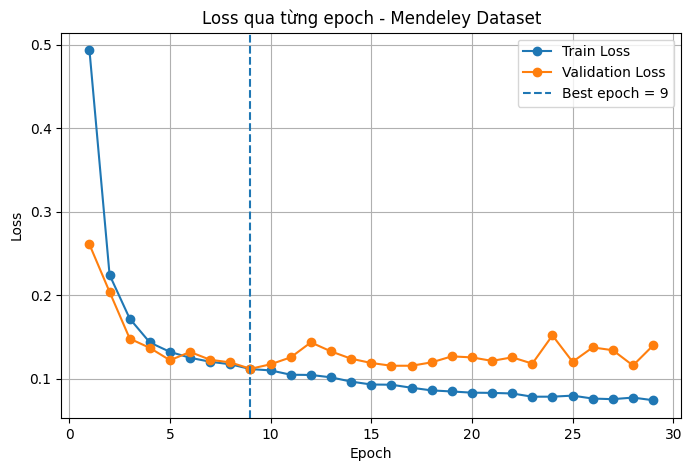

In [ ]:
# Biểu đồ loss.
plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs, history["val_loss"], marker="o", label="Validation Loss")
plt.axvline(best_epoch, linestyle="--", label=f"Best epoch = {best_epoch}")
plt.title("Loss qua từng epoch - Mendeley Dataset")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig("mendeley_loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

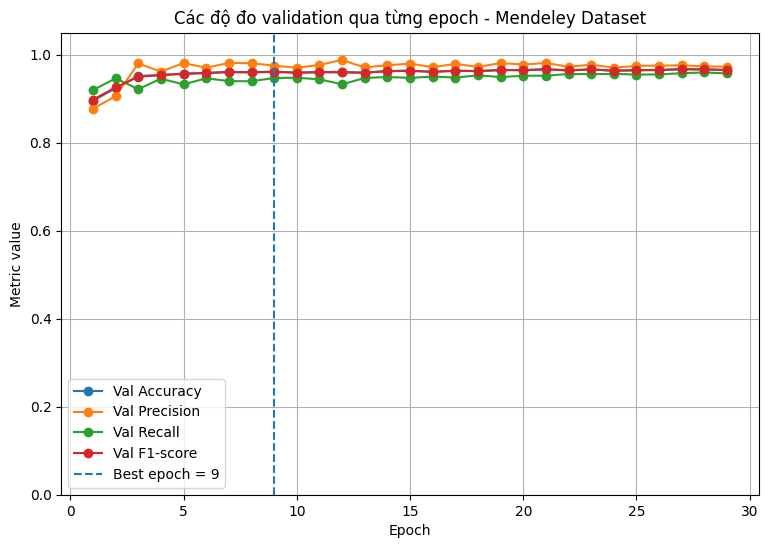

In [ ]:
# Biểu đồ metric validation.
plt.figure(figsize=(9, 6))
plt.plot(epochs, history["val_accuracy"], marker="o", label="Val Accuracy")
plt.plot(epochs, history["val_precision"], marker="o", label="Val Precision")
plt.plot(epochs, history["val_recall"], marker="o", label="Val Recall")
plt.plot(epochs, history["val_f1"], marker="o", label="Val F1-score")
plt.axvline(best_epoch, linestyle="--", label=f"Best epoch = {best_epoch}")
plt.title("Các độ đo validation qua từng epoch - Mendeley Dataset")
plt.xlabel("Epoch")
plt.ylabel("Metric value")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.savefig("mendeley_metrics_curve.png", dpi=300, bbox_inches="tight")
plt.show()

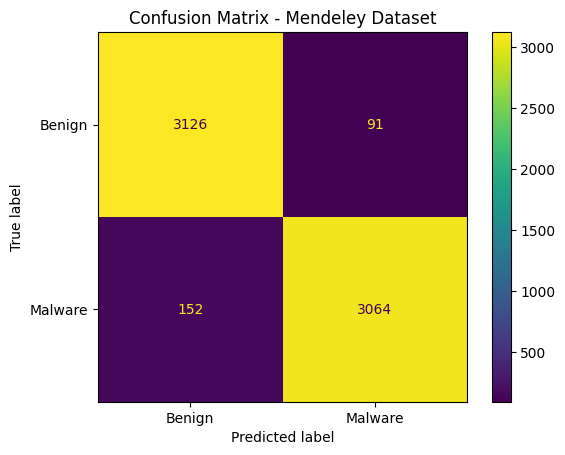

In [ ]:
# Vẽ confusion matrix.
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malware"]
)

disp.plot(values_format="d")
plt.title("Confusion Matrix - Mendeley Dataset")
plt.savefig("mendeley_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

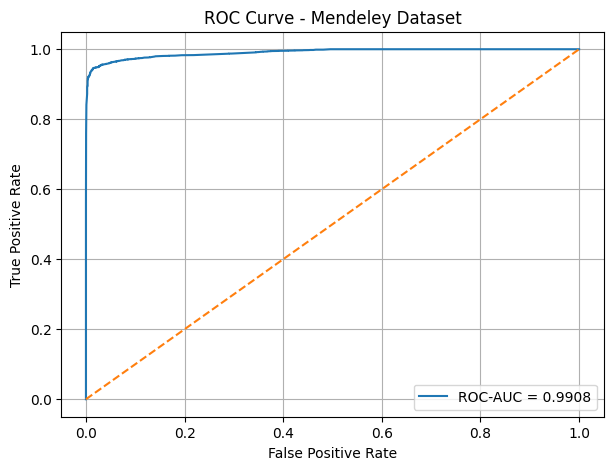

In [ ]:
# ROC curve.
fpr, tpr, _ = roc_curve(y_true, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve - Mendeley Dataset")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.savefig("mendeley_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

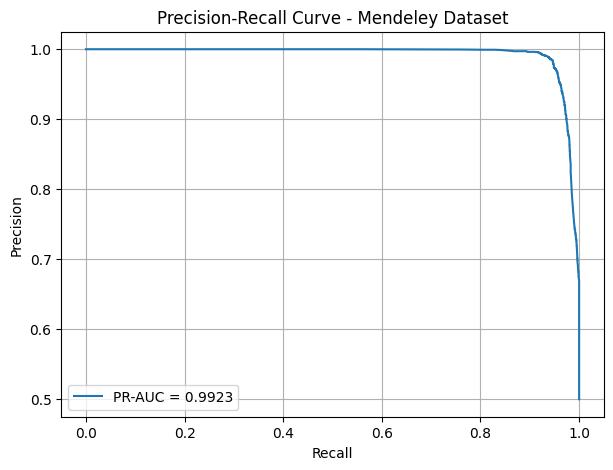

In [ ]:
# Precision-Recall curve.
precisions, recalls, _ = precision_recall_curve(y_true, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(recalls, precisions, label=f"PR-AUC = {pr_auc:.4f}")
plt.title("Precision-Recall Curve - Mendeley Dataset")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.savefig("mendeley_precision_recall_curve.png", dpi=300, bbox_inches="tight")
plt.show()

## 17. Lưu mô hình, tokenizer và nén kết quả

In [ ]:
# Tạo thư mục lưu mô hình.
os.makedirs("saved_model_mendeley", exist_ok=True)

# Lưu trọng số mô hình.
torch.save(
    model.state_dict(),
    "saved_model_mendeley/distilbertroid_permission_mendeley.pt"
)

# Lưu tokenizer.
tokenizer.save_pretrained("saved_model_mendeley/tokenizer")

# Lưu cấu hình thực nghiệm.
experiment_config = {
    "dataset": "Mendeley Android permissions dataset",
    "model": "DistilBERTroid-Permission-Mendeley",
    "model_name": MODEL_NAME,
    "target_samples_per_class": TARGET_SAMPLES_PER_CLASS,
    "samples_per_class_used": int(samples_per_class),
    "max_len": int(MAX_LEN),
    "batch_size": int(BATCH_SIZE),
    "epochs_max": int(EPOCHS),
    "patience": int(PATIENCE),
    "early_stop_metric": EARLY_STOP_METRIC,
    "best_epoch": int(best_epoch),
    "best_metric_value": float(best_metric_value),
    "best_threshold": float(BEST_THRESHOLD),
    "device": str(device),
    "use_amp": bool(USE_AMP)
}

with open("mendeley_experiment_config.json", "w", encoding="utf-8") as f:
    json.dump(experiment_config, f, ensure_ascii=False, indent=2)

print("Đã lưu mô hình, tokenizer và cấu hình.")

Đã lưu mô hình, tokenizer và cấu hình.


In [ ]:
# Danh sách file kết quả cần nộp kèm.
result_files = [
    "mendeley_permissions_dataset_standardized.csv",
    "mendeley_permissions_dataset_experiment.csv",
    "mendeley_processed_summary.csv",
    "mendeley_experiment_summary.csv",
    "mendeley_split_summary.csv",
    "baseline_results.csv",
    "mendeley_training_config.csv",
    "mendeley_training_history.csv",
    "mendeley_threshold_tuning.csv",
    "mendeley_test_results.csv",
    "mendeley_model_comparison.csv",
    "mendeley_classification_report.csv",
    "mendeley_confusion_matrix_table.csv",
    "mendeley_loss_curve.png",
    "mendeley_metrics_curve.png",
    "mendeley_confusion_matrix.png",
    "mendeley_roc_curve.png",
    "mendeley_precision_recall_curve.png",
    "mendeley_experiment_config.json"
]

zip_name = "mendeley_distilbertroid_results.zip"

with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file in result_files:
        if os.path.exists(file):
            zipf.write(file)

    # Nén thêm model nếu muốn.
    for root, dirs, files_in_dir in os.walk("saved_model_mendeley"):
        for file in files_in_dir:
            path = os.path.join(root, file)
            zipf.write(path)

print("Đã tạo file:", zip_name)

# Tải về máy.
files.download(zip_name)

Đã tạo file: mendeley_distilbertroid_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>